In [57]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from stable_baselines3 import DQN, PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy


In [58]:

log_dir = "cartpole_logs"
os.makedirs(log_dir, exist_ok=True)

env = gym.make("CartPole-v1")
env = Monitor(env, log_dir)


In [59]:
model = DQN(
    "MlpPolicy",
    env,
    learning_rate=1e-3,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=32,
    gamma=0.99,
    verbose=1
)


Using cpu device
Wrapping the env in a DummyVecEnv.


In [60]:
model.learn(total_timesteps=10000)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 24.8     |
|    ep_rew_mean      | 24.8     |
|    exploration_rate | 0.906    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 11956    |
|    time_elapsed     | 0        |
|    total_timesteps  | 99       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23.4     |
|    ep_rew_mean      | 23.4     |
|    exploration_rate | 0.822    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 12046    |
|    time_elapsed     | 0        |
|    total_timesteps  | 187      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23.8     |
|    ep_rew_mean      | 23.8     |
|    exploration_rate | 0.728    |
| time/               |          |
|    episodes       

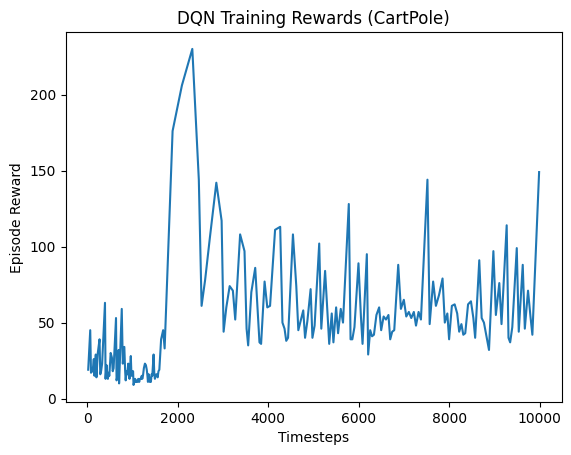

In [61]:
monitor_file = [f for f in os.listdir(log_dir) if f.endswith("monitor.csv")][0]
data = pd.read_csv(os.path.join(log_dir, monitor_file), skiprows=1)

rewards = data["r"].values
timesteps = np.cumsum(data["l"].values)

plt.figure()
plt.plot(timesteps, rewards)
plt.title("DQN Training Rewards (CartPole)")
plt.xlabel("Timesteps")
plt.ylabel("Episode Reward")
plt.show()


In [62]:
eval_env = gym.make("CartPole-v1")

mean_reward, std_reward = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=1000
)

print("DQN Mean Reward:", mean_reward)
print("DQN Std Reward:", std_reward)


/home/aadharsh-venkat/py310env/lib/python3.10/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


DQN Mean Reward: 99.032
DQN Std Reward: 67.03614678664042


In [63]:
ppo_log_dir = "cartpole_ppo_logs"
os.makedirs(ppo_log_dir, exist_ok=True)

ppo_env = gym.make("CartPole-v1")
ppo_env = Monitor(ppo_env, ppo_log_dir)


In [64]:
ppo_model = PPO(
    "MlpPolicy",
    ppo_env,
    learning_rate=3e-4,
    gamma=0.99,
    verbose=1
)

ppo_model.learn(total_timesteps=10000)


Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 20.9     |
|    ep_rew_mean     | 20.9     |
| time/              |          |
|    fps             | 2043     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 27.1        |
|    ep_rew_mean          | 27.1        |
| time/                   |             |
|    fps                  | 1360        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010001775 |
|    clip_fraction        | 0.0871      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.686      |
|    explained_varia

In [65]:
ppo_files = [f for f in os.listdir(ppo_log_dir) if f.endswith("monitor.csv")]
ppo_data = pd.read_csv(os.path.join(ppo_log_dir, ppo_files[0]), skiprows=1)

ppo_rewards = ppo_data["r"].values
ppo_timesteps = np.cumsum(ppo_data["l"].values)


In [66]:
eval_env = gym.make("CartPole-v1")

mean_reward, std_reward = evaluate_policy(
    ppo_model,
    eval_env,
    n_eval_episodes=10
)

print(mean_reward, std_reward)


/home/aadharsh-venkat/py310env/lib/python3.10/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


442.5 77.94902180271411


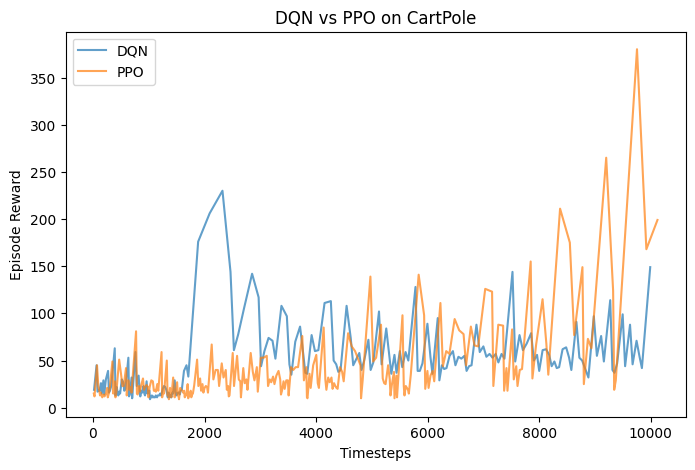

In [67]:
plt.figure(figsize=(8,5))
plt.plot(timesteps, rewards, label="DQN", alpha=0.7)
plt.plot(ppo_timesteps, ppo_rewards, label="PPO", alpha=0.7)

plt.xlabel("Timesteps")
plt.ylabel("Episode Reward")
plt.title("DQN vs PPO on CartPole")
plt.legend()
plt.show()


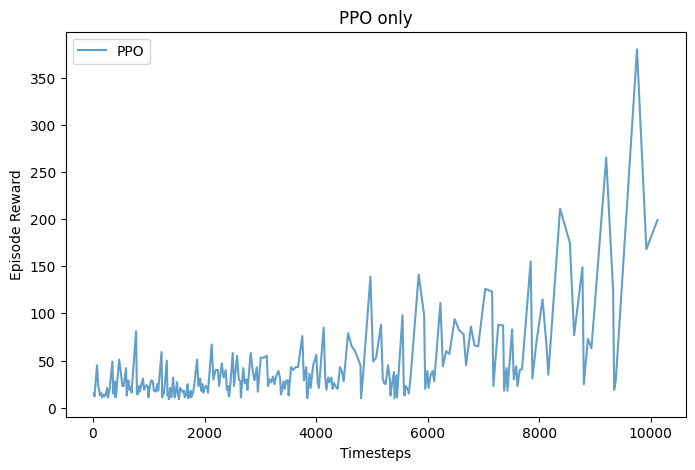

In [68]:
plt.figure(figsize=(8,5))
plt.plot(ppo_timesteps, ppo_rewards, label="PPO", alpha=0.7)
plt.xlabel("Timesteps")
plt.ylabel("Episode Reward")
plt.title("PPO only")
plt.legend()
plt.show()
